In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# 1

X = np.random.randint(0, 100, (3, 4))
Y = np.random.randint(0, 100, (2, 4))

# with loop:
def pairwise_sqdist_slow(X, Y):
    n, d = X.shape
    m = Y.shape[0]
    D = np.empty((n, m), dtype=float)
    for i in range(n):
        for j in range(m):
            s = 0.0
            for k in range(d):
                diff = X[i,k] - Y[j,k]
                s += diff**2
            D[i,j] = s
    return D

print(X)
print("-----------")
print(Y)
print("-----------")
print(pairwise_sqdist_slow(X, Y))
print("-----------")

# with numpy:
X_sq = np.sum(X**2, axis=1, keepdims=True)
Y_sq = np.sum(Y**2, axis=1, keepdims=True).T
print(X_sq + Y_sq - 2 * X @ Y.T)


[[54 57  9 55]
 [39 79 51 54]
 [75 87 96 98]]
-----------
[[29 97 86 47]
 [40 99 86 30]]
-----------
[[8218. 8514.]
 [1698. 2202.]
 [4917. 6093.]]
-----------
[[8218 8514]
 [1698 2202]
 [4917 6093]]


In [4]:
# 2

a = np.random.randint(0, 10, (10))

# with loop:
def moving_avg_slow(a, w):
    out = np.empty(len(a) - w + 1, dtype=float)
    for i in range(len(out)):
        out[i] = a[i:i+w].mean()
    return out

print(a)
print("-----------")
print(moving_avg_slow(a, 3))
print("-----------")


# with numpy:
w = 3
n = len(a) - w + 1
stride = a.strides[0]
print(np.lib.stride_tricks.as_strided(a, shape=(n, w), strides=(stride, stride)).mean(axis=1))
print("-----------")
print(np.lib.stride_tricks.sliding_window_view(a, 3).mean(axis=1))

[8 2 9 7 3 9 6 1 9 0]
-----------
[6.33333333 6.         6.33333333 6.33333333 6.         5.33333333
 5.33333333 3.33333333]
-----------
[6.33333333 6.         6.33333333 6.33333333 6.         5.33333333
 5.33333333 3.33333333]
-----------
[6.33333333 6.         6.33333333 6.33333333 6.         5.33333333
 5.33333333 3.33333333]


In [5]:
# 3

X = np.random.randint(0, 10, (3,4))

# with loop:
def normalize_row(X):
    Xn = X.copy().astype(float)
    for i in range(X.shape[0]):
        norm = np.sqrt((Xn[i]**2).sum())
        if norm != 0:
            Xn[i] /= norm
        else:
            Xn[i] = 0
            
    return Xn

print(X)
print("-----------")
print(normalize_row(X))
print("-----------")

# with numpy:
print(X/(np.linalg.norm(X, axis=1, keepdims=True)))

[[6 7 1 0]
 [0 1 6 3]
 [9 6 1 7]]
-----------
[[0.64699664 0.75482941 0.10783277 0.        ]
 [0.         0.14744196 0.88465174 0.44232587]
 [0.69644091 0.46429394 0.07738232 0.54167626]]
-----------
[[0.64699664 0.75482941 0.10783277 0.        ]
 [0.         0.14744196 0.88465174 0.44232587]
 [0.69644091 0.46429394 0.07738232 0.54167626]]


In [6]:
# 4

values = np.random.randint(0, 10, 5)
labels = np.random.randint(0, 2, 5)

# with loop:
def group_sum_slow(values, labels, n_groups):
    out = np.zeros(n_groups, dtype=values.dtype)
    for v, g in zip(values, labels):
        out[g] += v
    return out

print(values)
print("-----------")
print(labels)
print("-----------")
print(group_sum_slow(values, labels, 2))
print("-----------")

print(np.bincount(labels, values, 2))
print("-----------")

result_fast2 = np.zeros(2, dtype=values.dtype)
np.add.at(result_fast2, labels, values)
print(result_fast2)

[2 2 8 8 8]
-----------
[0 1 1 1 0]
-----------
[10 18]
-----------
[10. 18.]
-----------
[10 18]


In [7]:
# 5

x = np.random.randint(0, 100, 5)
y = np.arange(0,5)
bins = 5

# with loop:
def hist2d_slow(x, y, bins, xmin, xmax, ymin, ymax):
    H = np.zeros((bins, bins), dtype=int)
    for xi, yi in zip(x, y):
        bx = int((xi - xmin) / (xmax - xmin) * bins)
        by = int((yi - ymin) / (ymax - ymin) * bins)
        if 0 <= bx < bins and 0 <= by < bins:
            H[by, bx] += 1
    return H


print(values)
print("-----------")
print(labels)
print("-----------")
print(hist2d_slow(x, y, bins, min(x), max(x), min(y), max(y)))
print("-----------")

H, xedges, yedges = np.histogram2d(x, y, bins=bins, 
                                        range=[[min(x), max(x)], [min(y), max(y)]])
print(H.astype(int).T)

[2 2 8 8 8]
-----------
[0 1 1 1 0]
-----------
[[1 0 0 0 0]
 [1 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 1]
 [0 0 0 0 0]]
-----------
[[1 0 0 0 0]
 [1 0 0 0 0]
 [0 0 0 0 1]
 [0 0 0 0 1]
 [1 0 0 0 0]]


In [8]:
# 6 

a = np.random.randint(0, 100, 20)
lo = 25
hi = 75

# with loop:
def clamp_slow(a, lo, hi):
    out = a.copy()
    for i in range(len(out)):
        if out[i] < lo:
            out[i] = lo
        elif out[i] > hi:
            out[i] = hi
    return out

print(a)
print("-----------")
print(clamp_slow(a, lo, hi))
print("-----------")
print(np.where(a < lo, lo, np.where(a > hi, hi, a)))
print("-----------")
print(np.clip(a, lo, hi))

[63  5 63 46 57 28 34 34  2  1 78 45 52 98 37 93  2 65 68 36]
-----------
[63 25 63 46 57 28 34 34 25 25 75 45 52 75 37 75 25 65 68 36]
-----------
[63 25 63 46 57 28 34 34 25 25 75 45 52 75 37 75 25 65 68 36]
-----------
[63 25 63 46 57 28 34 34 25 25 75 45 52 75 37 75 25 65 68 36]


In [9]:
# 7 

X = np.random.randint(0, 100, (4,5))

def corr_slow(X):
    n, d = X.shape
    C = np.empty((d, d), dtype=float)
    means = X.mean(axis=0)
    stds = X.std(axis=0, ddof=1)
    
    for i in range(d):
        xi = X[:, i] - means[i]
        for j in range(d):
            xj = X[:, j] - means[j]
            cov = (xi * xj).sum() / (n - 1)
            C[i, j] = cov / (stds[i] * stds[j])
    return C

print(X)
print("-----------")
print(corr_slow(X))
print("-----------")

n, d = X.shape
means = X.mean(axis=0)
stds = X.std(axis=0, ddof=1)
Xc = X - means

cov_matrix = (Xc.T @ Xc) / (n - 1)
corr_matrix = cov_matrix / np.outer(stds, stds)

print(corr_matrix)

[[72 24 92 66 96]
 [32 94 98  1 91]
 [34 50 47 47 20]
 [69 80 95 76 58]]
-----------
[[ 1.         -0.43110577  0.46607553  0.82850663  0.34629812]
 [-0.43110577  1.          0.34715418 -0.53577878  0.02061823]
 [ 0.46607553  0.34715418  1.         -0.07105608  0.86697589]
 [ 0.82850663 -0.53577878 -0.07105608  1.         -0.23177745]
 [ 0.34629812  0.02061823  0.86697589 -0.23177745  1.        ]]
-----------
[[ 1.         -0.43110577  0.46607553  0.82850663  0.34629812]
 [-0.43110577  1.          0.34715418 -0.53577878  0.02061823]
 [ 0.46607553  0.34715418  1.         -0.07105608  0.86697589]
 [ 0.82850663 -0.53577878 -0.07105608  1.         -0.23177745]
 [ 0.34629812  0.02061823  0.86697589 -0.23177745  1.        ]]


In [10]:
# 8

A = np.random.randint(0, 100, (4,5))
k = 3

# with loop:
def topk_idx_slow(A, k):
    idx = np.empty((A.shape[0], k), dtype=int)
    for i in range(A.shape[0]):
        idx[i] = np.argsort(A[i])[::-1][:k]
    return idx

print(A)
print("-----------")
print(topk_idx_slow(A, k))
print("-----------")
print(np.argsort(-A, axis=1)[:, :k])

[[23 71 73 12 30]
 [76 65 80 81 57]
 [28 34 10  2 30]
 [94  2 45 32 78]]
-----------
[[2 1 4]
 [3 2 0]
 [1 4 0]
 [0 4 2]]
-----------
[[2 1 4]
 [3 2 0]
 [1 4 0]
 [0 4 2]]


In [11]:
# 9

img = np.random.randint(0, 100, (270, 360))
k = 5

def mean_filter_slow(img, k):
    h, w = img.shape
    out = np.zeros((h-k+1, w-k+1), dtype=float)
    for i in range(h-k+1):
        for j in range(w-k+1):
            out[i, j] = img[i:i+k, j:j+k].mean()
    return out
            
print(img)
print("-----------")
print(mean_filter_slow(img, k))
print("-----------")
print(np.lib.stride_tricks.sliding_window_view(img,(k,k)).mean(axis=(-2, -1)))

[[10 36 49 ... 70 79 19]
 [55 87 85 ... 29 41 66]
 [21  2 15 ... 94 73 73]
 ...
 [59 23 67 ...  7 70 13]
 [ 0 88 10 ... 50 18 55]
 [72 99 16 ... 41 86 73]]
-----------
[[50.84 56.4  57.12 ... 47.04 47.96 44.88]
 [55.4  55.72 54.28 ... 44.6  42.84 39.56]
 [52.   50.16 47.44 ... 44.96 44.   39.6 ]
 ...
 [45.04 41.28 45.88 ... 48.08 50.08 51.28]
 [44.64 43.68 48.2  ... 46.44 46.04 44.32]
 [52.04 50.52 52.72 ... 45.08 44.08 45.08]]
-----------
[[50.84 56.4  57.12 ... 47.04 47.96 44.88]
 [55.4  55.72 54.28 ... 44.6  42.84 39.56]
 [52.   50.16 47.44 ... 44.96 44.   39.6 ]
 ...
 [45.04 41.28 45.88 ... 48.08 50.08 51.28]
 [44.64 43.68 48.2  ... 46.44 46.04 44.32]
 [52.04 50.52 52.72 ... 45.08 44.08 45.08]]


In [12]:
# 10

rows = np.random.randint(0, 100, 15)
cols = np.random.randint(0, 100, 15)
shape = 5

def count_sparse_slow(cols, rows, shape):
    counts = {}
    for r, c in zip(rows, cols):
        key = (r, c)
        counts[key] = counts.get(key, 0)+1
        
    mat = np.zeros(shape, dtype=int)
    for (r, c), count in counts.items():
        if r < shape and c < shape:
            mat[r, c] = count
            
    return mat

print(rows)
print("-----------")
print(count_sparse_slow(cols, rows, shape))
print("-----------")
        

[ 3  1 29  3 35 68 85 64  1 89 46 46 16 48 32]
-----------
[0 0 0 0 0]
-----------


In [13]:
# 11

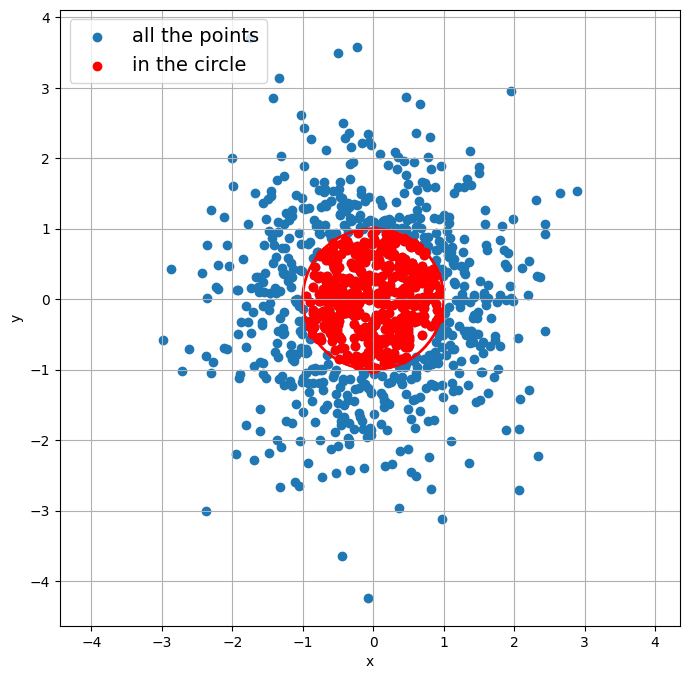

-----------


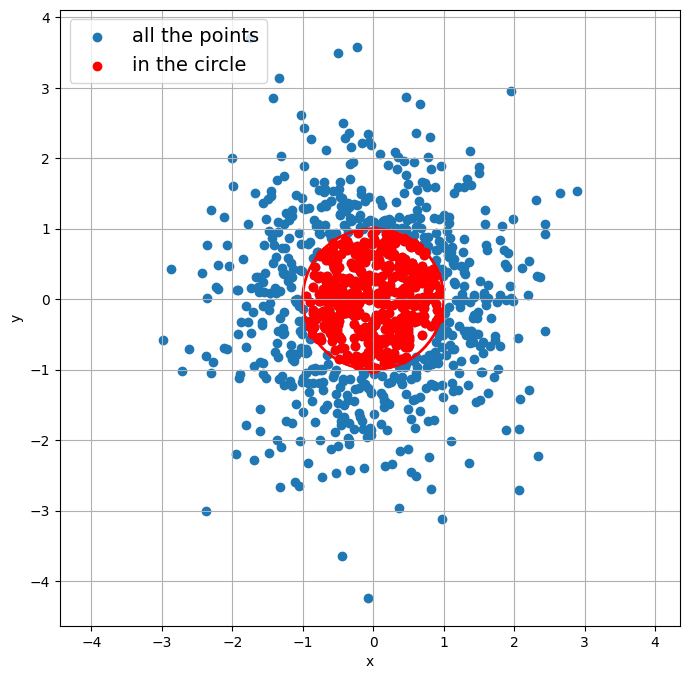

In [67]:
# 12

p = np.random.randn(1000, 2)
cx, cy = 0, 0
r = 1

def points_in_circle_slow(p, cx, cy, r):
    inside = []
    for i in range(p.shape[0]):
        x, y = p[i]
        dist_sq = (x - cx)**2 + (y - cy)**2
        if dist_sq < r:
            inside.append(p[i])
    return np.array(inside)


inside = points_in_circle_slow(p, cx, cy, r)

plt.figure(figsize=(8, 8))
plt.xlabel("x")
plt.ylabel("y")
plt.scatter(x=(p[:, 0]), y=(p[:, 1]))
plt.scatter(x=(inside[:, 0]), y=(inside[:, 1]), color="red")
plt.grid(True)
plt.legend(['all the points', 'in the circle'], loc=2, fontsize=14)

# Add the circle
circle = plt.Circle((cx, cy), r, color='red', fill=False, linewidth=2)
plt.gca().add_artist(circle)
plt.axis('equal')  # Make the circle appear circular

plt.show()


print("-----------")
inside = p[((p[:, 0])**2)+((p[:, 1])**2)<1]
plt.figure(figsize=(8, 8))
plt.xlabel("x")
plt.ylabel("y")
plt.scatter(x=(p[:, 0]), y=(p[:, 1]))
plt.scatter(x=(inside[:, 0]), y=(inside[:, 1]), color="red")
plt.grid(True)
plt.legend(['all the points', 'in the circle'], loc=2, fontsize=14)
circle = plt.Circle((cx, cy), r, color='red', fill=False, linewidth=2)
plt.gca().add_artist(circle)
plt.axis('equal')  # Make the circle appear circular

plt.show()


In [103]:
# 13

X = np.random.randint(0, 100, (3, 4))
X_centered = X - X.mean(axis=1, keepdims=True)
X_centered.mean()

def custom_cov_slow(X_centered):
    n, d = X_centered.shape 
    C = np.empty((d, d), float)
    for i in range(d):
        for j in range(d):
            C[i, j] = (X_centered[:, i] * X_centered[:, j]).sum() / (n-1)
            
    return C

n = X_centered.shape[0]
print(X_centered)
print("-----------")
print(custom_cov_slow(X_centered))
print("-----------")
print(X_centered.T @ X_centered/(n-1))

[[  8.5 -23.5  -9.5  24.5]
 [ 20.   -8.   17.  -29. ]
 [-23.5   5.5  11.5   6.5]]
-----------
[[ 512.25 -244.5    -5.5  -262.25]
 [-244.5   323.25   75.25 -154.  ]
 [  -5.5    75.25  255.75 -325.5 ]
 [-262.25 -154.   -325.5   741.75]]
-----------
[[ 512.25 -244.5    -5.5  -262.25]
 [-244.5   323.25   75.25 -154.  ]
 [  -5.5    75.25  255.75 -325.5 ]
 [-262.25 -154.   -325.5   741.75]]
